# Dense HEA LeJEPA on Synthetic Disc-Square Data

This notebook uses the synthetic **disc with two interior squares** dataset for dense LeJEPA-style representation learning.

Each `128 x 128` image contains:
- background with density `0.0`
- a centered disc with density `1.0`
- one square near the disc edge
- one square farther from the edge
- square densities `0.5` and `0.25`
- two disc radii and two square-size states

The 8 canonical types are the cartesian product of:
- 2 disc radii
- 2 square sizes
- 2 assignments of densities across the near/far squares

The model is the **teacher-free dense HEA LeJEPA adaptor**. It learns a dense latent field from multiple aligned augmented views of each synthetic image.

In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from local_conv_attention import (
    DenseLeJEPAModel,
    DiscSquareDataset,
    default_all_latent_hooks,
    generate_disc_square_image,
    load_experiment_config,
    make_disc_square_types,
)

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("Project root:", PROJECT_ROOT)
print("Device:", device)

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

Project root: /Users/phzwart/Projects/convtrans
Device: mps


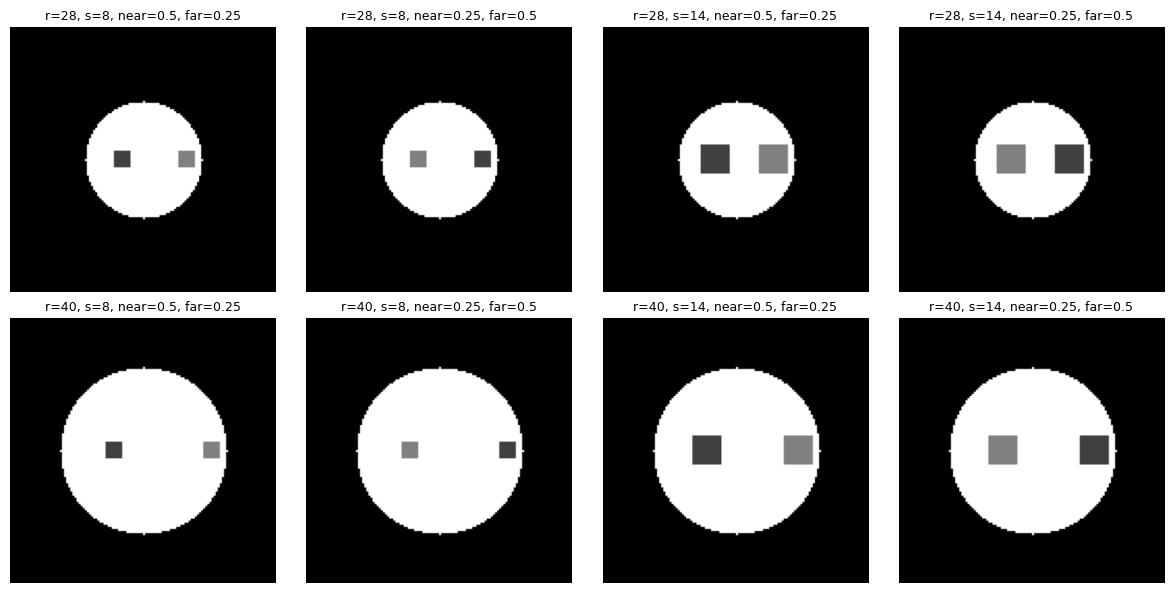

In [2]:
canonical_specs = make_disc_square_types()
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, spec in zip(axes.flat, canonical_specs):
    image = generate_disc_square_image(spec)[0]
    axis.imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
    axis.set_title(
        f"r={spec.radius}, s={spec.square_size}, near={spec.near_density}, far={spec.far_density}",
        fontsize=9,
    )
    axis.axis("off")
plt.tight_layout()

In [18]:
train_dataset = DiscSquareDataset(repeats_per_type=256)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, drop_last=True)

print("Dataset size:", len(train_dataset))
sample = train_dataset[0]
print("Sample keys:", sample.keys())
print("Sample image shape:", tuple(sample["image"].shape))
print(
    "Sample metadata:",
    {
        "type_index": sample["type_index"],
        "radius": sample["radius"],
        "square_size": sample["square_size"],
        "near_density": sample["near_density"],
        "far_density": sample["far_density"],
    },
)

Dataset size: 2048
Sample keys: dict_keys(['image', 'type_index', 'radius', 'near_density', 'far_density', 'square_size'])
Sample image shape: (1, 128, 128)
Sample metadata: {'type_index': 0, 'radius': 28, 'square_size': 8, 'near_density': 0.5, 'far_density': 0.25}


In [19]:
config = load_experiment_config(PROJECT_ROOT / "configs" / "hea_dense_lejepa_default.yaml")
config.model.in_channels = 1
config.model.base_channels = 16
config.model.channel_multipliers = [1, 2, 4, 8]
config.model.encoder_depths = [1, 1, 1, 1]
config.model.decoder_depths = [1, 1, 1]
config.model.attention.heads = 4
config.model.attention.head_dim = 16
config.model.attention.operator_backend = "optimized"

# Train dense LeJEPA at every pyramid hook (encoders, bottleneck, decoders, top).
config.model.latent.sources = default_all_latent_hooks(len(config.model.channel_multipliers))
config.model.latent.step_mode = "rotate"  # one hook per batch; use "joint" to average all each step
config.model.latent.latent_dim = 32
config.model.latent.projector_depth = 1
config.model.latent.normalize_latents = False

# Keep HEA present but lightweight.
config.model.hea.enabled_decoder_stages = [0]
config.model.semantic_memory.window_sizes = [7, 7, 7]
config.model.hea.per_scale_window_sizes = [7, 7, 7]

# Symmetric dense LeJEPA settings.
config.model.lejepa.num_views = 4
config.model.lejepa.sequential_view_forward = True  # lowers peak VRAM vs fusing views
config.model.lejepa.lambda_sigreg = 0.05
config.model.lejepa.sigreg.enabled = True
config.model.lejepa.sigreg.num_slices = 64
config.model.lejepa.sigreg.num_knots = 17
config.model.lejepa.sigreg.per_view = True

# Geometry stays aligned; augmentations are photometric/corruption only.
config.model.lejepa.views.mode = "aligned_same_geometry"
config.model.lejepa.views.corruption.intensity_jitter = True
config.model.lejepa.views.corruption.blur = False
config.model.lejepa.views.corruption.gaussian_noise = True
config.model.lejepa.views.corruption.random_block_mask = True
config.model.lejepa.views.corruption.block_mask_ratio = 0.04
config.model.lejepa.views.corruption.block_mask_num_blocks = 4

config.validate()

model = DenseLeJEPAModel(config.model).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Model parameters: {num_params:,}")

Model parameters: 1,106,624


In [ ]:
def train_dense_lejepa(model, loader, optimizer, *, epochs: int = 20) -> dict[str, list[float]]:
    history = {"loss": [], "inv_loss": [], "sigreg_loss": []}
    global_step = 0
    for epoch in range(epochs):
        model.train()
        running = {key: 0.0 for key in history}
        batches = 0
        for batch in loader:
            images = batch["image"].to(device)
            optimizer.zero_grad(set_to_none=True)
            out = model(images, rotate_latent_index=global_step)
            global_step += 1
            out["loss"].backward()
            optimizer.step()
            for key in history:
                running[key] += float(out[key].detach())
            batches += 1
        for key in history:
            history[key].append(running[key] / max(1, batches))
        print(
            f"epoch {epoch + 1:02d} | loss={history['loss'][-1]:.4f} | "
            f"inv={history['inv_loss'][-1]:.4f} | sigreg={history['sigreg_loss'][-1]:.4f}"
        )
    return history


history = train_dense_lejepa(model, train_loader, optimizer, epochs=50)

epoch 01 | loss=0.0138 | inv=0.0062 | sigreg=0.1586


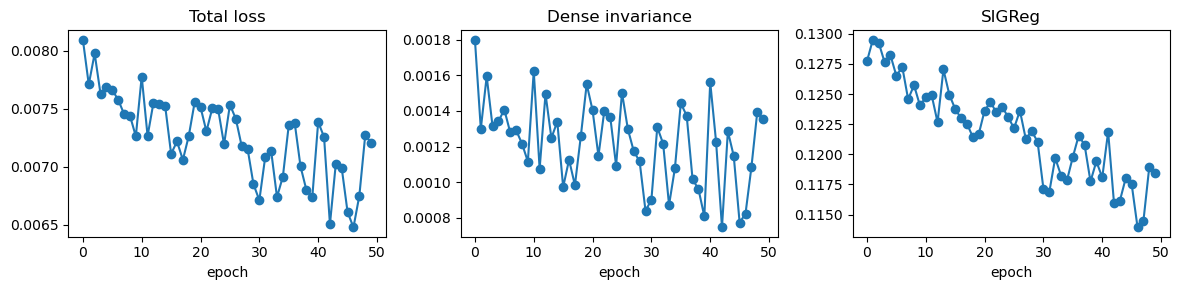

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].plot(history["loss"], marker="o")
axes[0].set_title("Total loss")
axes[1].plot(history["inv_loss"], marker="o")
axes[1].set_title("Dense invariance")
axes[2].plot(history["sigreg_loss"], marker="o")
axes[2].set_title("SIGReg")
for ax in axes:
    ax.set_xlabel("epoch")
plt.tight_layout()

Dense latent map shape: (32, 128, 128)


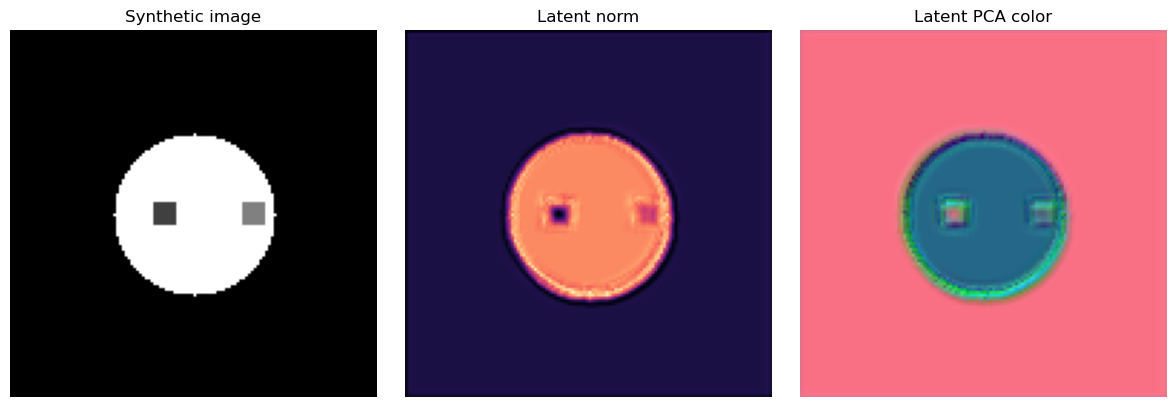

In [22]:
@torch.no_grad()
def extract_dense_latent_map(model, image: torch.Tensor) -> torch.Tensor:
    model.eval()
    image = image.unsqueeze(0).to(device)
    features = model.backbone(image)
    latents = model.projector(features)
    return latents[0].cpu()


def pca_colorize_latents(latent_map: torch.Tensor) -> np.ndarray:
    channels, height, width = latent_map.shape
    flat = latent_map.reshape(channels, -1).T.numpy()
    flat = flat - flat.mean(axis=0, keepdims=True)
    _, _, vh = np.linalg.svd(flat, full_matrices=False)
    coords = flat @ vh[:3].T
    coords = (coords - coords.min(axis=0, keepdims=True)) / (
        coords.max(axis=0, keepdims=True) - coords.min(axis=0, keepdims=True) + 1e-6
    )
    return coords.reshape(height, width, 3)


eval_sample = train_dataset[0]
image = eval_sample["image"]
latent_map = extract_dense_latent_map(model, image)
latent_norm = torch.linalg.vector_norm(latent_map, dim=0)
latent_pca = pca_colorize_latents(latent_map)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image[0], cmap="gray", vmin=0.0, vmax=1.0)
axes[0].set_title("Synthetic image")
axes[1].imshow(latent_norm, cmap="magma")
axes[1].set_title("Latent norm")
axes[2].imshow(latent_pca)
axes[2].set_title("Latent PCA color")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
print("Dense latent map shape:", tuple(latent_map.shape))

/var/folders/sg/flwdvpwj6k1djjf0wn8f9q2w0000gn/T/ipykernel_48499/1760186709.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


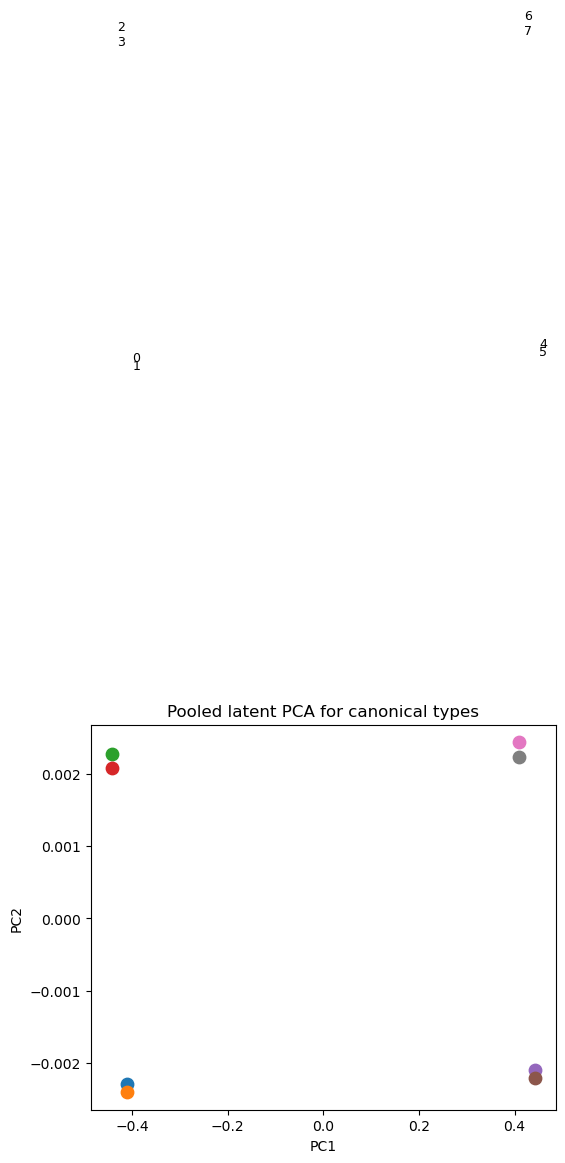

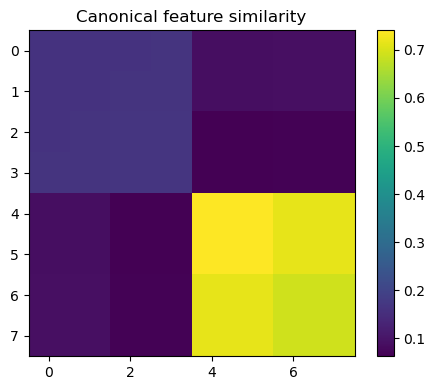

In [23]:
@torch.no_grad()
def build_canonical_feature_bank(model) -> tuple[np.ndarray, list[dict]]:
    pooled_features = []
    metadata = []
    for spec in canonical_specs:
        image = generate_disc_square_image(spec)
        latent = extract_dense_latent_map(model, image)
        pooled = latent.mean(dim=(1, 2))
        pooled_features.append(pooled.numpy())
        metadata.append(
            {
                "type_index": spec.type_index,
                "radius": spec.radius,
                "square_size": spec.square_size,
                "near_density": spec.near_density,
                "far_density": spec.far_density,
            }
        )
    return np.stack(pooled_features), metadata


feature_bank, feature_meta = build_canonical_feature_bank(model)
feature_bank_centered = feature_bank - feature_bank.mean(axis=0, keepdims=True)
_, _, vh = np.linalg.svd(feature_bank_centered, full_matrices=False)
feature_pca = feature_bank_centered @ vh[:2].T

plt.figure(figsize=(6, 5))
for point, meta in zip(feature_pca, feature_meta):
    label = f"r={meta['radius']}, s={meta['square_size']}, n={meta['near_density']}, f={meta['far_density']}"
    plt.scatter(point[0], point[1], s=80)
    plt.text(point[0] + 0.01, point[1] + 0.01, str(meta['type_index']), fontsize=9)
plt.title("Pooled latent PCA for canonical types")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()

similarity = feature_bank @ feature_bank.T
plt.figure(figsize=(5, 4))
plt.imshow(similarity, cmap="viridis")
plt.title("Canonical feature similarity")
plt.colorbar()
plt.tight_layout()

In [24]:
import napari
v = napari.Viewer()
v.add_image(latent_map)

<Image layer 'latent_map' at 0x54cc40a90>